## The Machine Learning Landscape
#### Suppose want to know if money makes people happy:

In [2]:
# Define font and plot figures:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [3]:
# Make output stable:
import numpy as np
np.random.seed(42)

In [25]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

In [5]:
# download GDP data
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")
lifesat

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6
5,Portugal,32181.154537,5.4
6,Poland,32238.157259,6.1
7,Estonia,35638.421351,5.7
8,Spain,36215.447591,6.3
9,Slovenia,36547.738956,5.9


In [14]:
# Prepare data
X = lifesat[['GDP per capita (USD)']].values
y = lifesat[['Life satisfaction']].values
y

array([[5.8],
       [5.4],
       [5.5],
       [5.9],
       [5.6],
       [5.4],
       [6.1],
       [5.7],
       [6.3],
       [5.9],
       [5.9],
       [7.2],
       [6. ],
       [6.8],
       [6.5],
       [7.3],
       [7.4],
       [7.6],
       [6.9],
       [7.3],
       [7.3],
       [7. ],
       [7.1],
       [7.5],
       [7.4],
       [7.6],
       [6.9]])

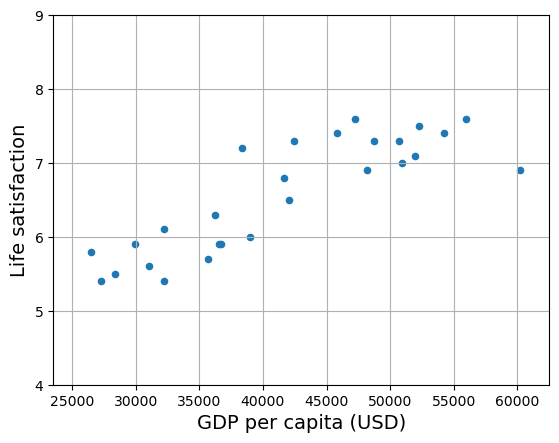

In [15]:
# Visualize the data
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.show()

In [16]:
# Decided to model life satisfaction as a linear function of GDP per capita.
# This step is called model selection.
# Selected a linear model of life satisfaction with just one attribute, GDP per capita
# life_satisfaction = θ 0 + θ 1 × GDP_per_capita
# This model has two model parameters, θ0 and θ1

In [17]:
# Select a linear model
model = LinearRegression()

In [18]:
# train model
model.fit(X, y)

LinearRegression()

In [26]:
# Make a prediction for Cyprus
# # Cyprus' GDP per capita in 2020
X_new = [[37_655.2]] 
predict_result = model.predict(X_new)
print(predict_result)

[[6.30165767]]


In [30]:
# If instance-based learning algorithm used instead
# The system learns the examples by heart, then generalizes to new cases by using a similarity measure to
# comparethem to the learned examples

In [29]:
# Select model:
model_k_nearest = KNeighborsRegressor(n_neighbors=3)

# Train the model
model_k_nearest.fit(X, y)

# Make a prediction for Cyprus
print(model_k_nearest.predict(X_new)) # outputs [[6.33333333]]

[[6.33333333]]


#### Poor Quality Data:
- If some instances are clearly outliers, it may help to simply discard them or try to fix the errors manually.
- If some instances are missing a few features (e.g., 5% of your customers did not specify their age), you must     decide whether you want to ignore this attribute altogether, ignore these instances, fill in the missing values(e.g., with the median age), or train one model with the feature and one model without it.

#### Irrelevant Features:
- Feature selection (selecting the most useful features to train on among existing features)
- Feature extraction (combining existing features to produce a more useful one⁠ —as we saw earlier, dimensionality reduction algorithms can help)
- Creating new features by gathering new data

#### Overfitting:
- Simplify the model by selecting one with fewer parameters (e.g., a linear model rather than a high-degree polynomial model), by reducing the number of attributes in the training data, or by constraining the model.
- Gather more training data.
- Reduce the noise in the training data (e.g., fix data errors and remove outliers).

### Testing and Validating:

- Split data into two sets: the training set and the test set. Train model using the training set, and test it using the test set. 
- The error rate on new cases is called the generalization error and by evaluating model on the test set, get an estimate of this error. This value tells how well the model will perform on instances it has never seen before.
- If the training error is low (i.e., your model makes few mistakes on the training set) but the generalization error is high, it means that your model is overfitting the training data.
- It is common to use 80% of the data for training and hold out 20% for testing.

### Hyperparameter Tuning and Model Selection:

- Step 1: Train and Compare Models
Train different types of models (e.g., linear vs. polynomial) and compare their performance using a test set.

- Step 2: Hyperparameter Tuning
Train multiple models with varying hyperparameter values to find the best-performing one based on generalization error.

- Step 3: Issue with Overfitting on Test Set
Recognize that repeated evaluations on the test set can lead to overfitting, causing poor performance on new data.

- Step 4: Holdout Validation Approach
Split the training set into a reduced training set and a validation set, train and evaluate models, then train the best model on the full training set and evaluate on the test set.

- Step 5: Validation Set Size Concerns
Ensure the validation set is neither too small to cause imprecise evaluations nor too large to significantly reduce the training set.

- Step 6: Cross-Validation Solution
Use repeated cross-validation with multiple small validation sets to obtain a more accurate measure of model performance, despite increased training time.

## Exercises
##### 1. How would you define machine learning?
Machine Learning is about building systems that can learn from data. Learning means getting better at some task, given some performance measure.
##### 2. Can you name four types of applications where it shines?
- Complex problems for which we have no algorithmic solution
- To replace long lists of hand-tuned rules
- To build systems that adapt to fluctuating environments
- So help humans learn (e.g., data mining).
##### 3. What is a labeled training set?
Training set that contains the desired solution (a.k.a. a label) for each instance.
##### 4. What are the two most common supervised tasks?
The two most common supervised tasks are regression and classification.
- Regression: Predicting a person's weight based on their height and age. Forecasting a company's quarterly sales revenue. Estimating the total amount of rainfall for a given day.
- Classification: Determining if a tumor is malignant or benign based on medical images. Classifying customer feedback as positive, neutral, or negative. Identifying the species of an animal in a photo as cat, dog, or bird.
##### 5. Can you name four common unsupervised tasks?
- Clustering: Grouping similar data points together based on their features.
- Visualization: Creating visual representations of data to help understand patterns and relationships.
- Dimensionality Reduction: Reducing the number of features in a dataset while preserving important information.
- Association Rule Learning: Discovering interesting relationships or patterns between variables in large datasets.
##### 6. What type of algorithm would you use to allow a robot to walk in various unknown terrains?
Reinforcement Learning is likely to perform best if we want a robot to learn to walk in various unknown terrains, since this is typically the type of problem that Reinforcement Learning tackles. It might be possible to express the problem as a supervised or semi-supervised learning problem, but it would be less natural.
##### 7. What type of algorithm would you use to segment your customers into multiple groups?
If you don't know how to define the groups, then you can use a clustering algorithm (unsupervised learning) to segment your customers into clusters of similar customers. However, if you know what groups you would like to have, then you can feed many examples of each group to a classification algorithm (supervised learning), and it will classify all your customers into these groups.
##### 8. Would you frame the problem of spam detection as a supervised learning problem or an unsupervised learning problem?
Spam detection is a typical supervised learning problem: the algorithm is fed many emails along with their labels (spam or not spam).
##### 9. What is an online learning system?
An online learning system can learn incrementally, as opposed to a batch learning system. This makes it capable of adapting rapidly to both changing data and autonomous systems, and of training on very large quantities of data.
##### 10. What is out-of-core learning?
Out-of-core algorithms can handle vast quantities of data that cannot fit in a computer's main memory. An out-of-core learning algorithm chops the data into mini-batches and uses online learning techniques to learn from these mini-batches.
##### 11. What type of algorithm relies on a similarity measure to make predictions?
An instance-based learning system learns the training data by heart; then, when given a new instance, it uses a similarity measure to find the most similar learned instances and uses them to make predictions.
##### 12. What is the difference between a model parameter and a model hyperparameter?
A model has one or more model parameters that determine what it will predict given a new instance (e.g., the slope of a linear model). A learning algorithm tries to find optimal values for these parameters such that the model generalizes well to new instances. A hyperparameter is a parameter of the learning algorithm itself, not of the model (e.g., the amount of regularization to apply).
- Model parameter: weight and bias
- Model hyperparameter: rate, number of layers, neurons, epochs
##### 13. What do model-based algorithms search for? What is the most common strategy they use to succeed? How do they make predictions?
Model-based learning algorithms search for an optimal value for the model parameters such that the model will generalize well to new instances. We usually train such systems by minimizing a cost function that measures how bad the system is at making predictions on the training data, plus a penalty for model complexity if the model is regularized. To make predictions, we feed the new instance's features into the model's prediction function, using the parameter values found by the learning algorithm.
##### 14. Can you name four of the main challenges in machine learning?
Some of the main challenges in Machine Learning are the lack of data, poor data quality, nonrepresentative data, uninformative features, excessively simple models that underfit the training data, and excessively complex models that overfit the data.
##### 15. If your model performs great on the training data but generalizes poorly to new instances, what is happening? Can you name three possible solutions?
If a model performs great on the training data but generalizes poorly to new instances, the model is likely overfitting the training data (or we got extremely lucky on the training data). Possible solutions to overfitting are getting more data, simplifying the model (selecting a simpler algorithm, reducing the number of parameters or features used, or regularizing the model), or reducing the noise in the training data.
##### 16. What is a test set, and why would you want to use it?
A test set is used to estimate the 'generalization error' that a model will make on new instances, before the model is launched in production.
##### 17. What is the purpose of a validation set?
A validation set is used to compare models. It makes it possible to select the best model and tune the hyperparameters.
##### 18. What is the train-dev set, when do you need it, and how do you use it?
The train-dev set is used when there is a risk of mismatch between the training data and the data used in the validation and test datasets (which should always be as close as possible to the data used once the model is in production). The train-dev set is a part of the training set that's held out (the model is not trained on it). The model is trained on the rest of the training set, and evaluated on both the train-dev set and the validation set. If the model performs well on the training set but not on the train-dev set, then the model is likely overfitting the training set. If it performs well on both the training set and the train-dev set, but not on the validation set, then there is probably a significant data mismatch between the training data and the validation + test data, and you should try to improve the training data to make it look more like the validation + test data.
##### 19. What can go wrong if you tune hyperparameters using the test set?
If you tune hyperparameters using the test set, you risk overfitting the test set, and the generalization error you measure will be optimistic (you may launch a model that performs worse than you expect).